### Objectives
- Create MCP serves in STIO and HTTP trasnprot using FastMCP
- Regiser custom tools, resources, and tprmpt s to an MCP server
- Test MCP serves with clietn connections and manual tool calling
- Create a multi server client and ReAct agent

### MCP server
- MCP server is like a remote library
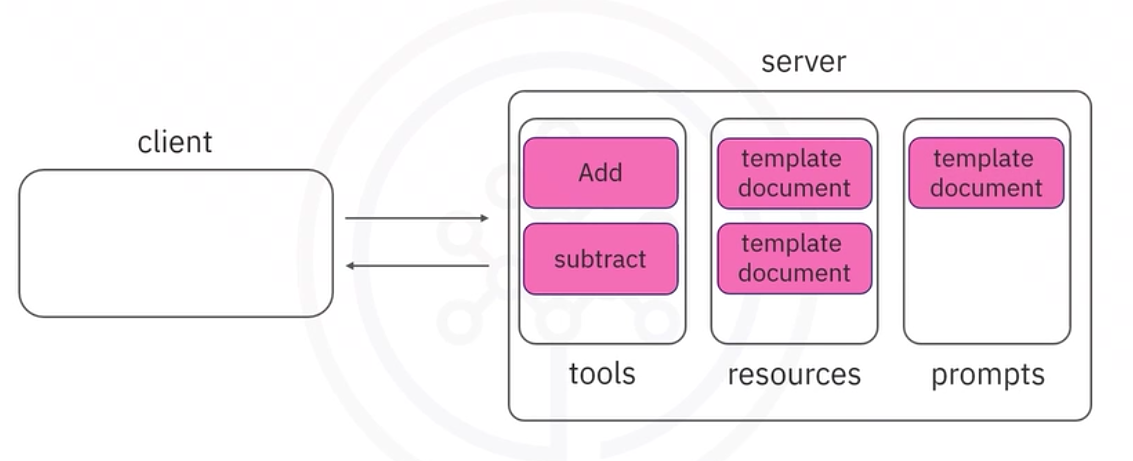

### MCP sever object
- create FastMCP sever object
```python
from fastmcp import FastMCP
mcp = FastMCP(
    name="CalculatorMCPSever",
    instructions="""
    This sever provides data analysis tools.
    Call get_average() to analyze numerical data.
    """
)
```
- `name` identifies the MCP sever
- `instructions` natural language docuemnation for the llm

### MCP tools
```python
@mcp.tool
def add(a:int, b:int) -> int:
    "Add two integers together"
    return a + b

@mcp.tool
def subtract(a: int, b: int) -> int:
    "subtract one integer from another"
    return a-b
```

### Resources
- filing cabinets that AI system can access
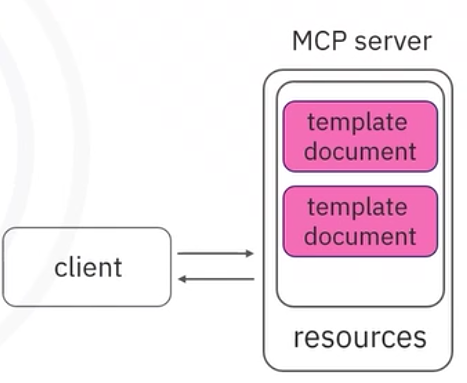
```python
@mcp.resource("file:///endpoint/{name}")
def return_template_document(name: str) -> str:
    """Read a document by name"""
    return f"Document contents of {name}"
```
- name: path parameter, that is an input to the function
- the resources retuns a file

```python
@mcp.resource("file//endpoint/{name}")

def read_document(name:str) -> str:
    "Read a document by name from the path directory"
    try:
        with open(f"path/{name}", "r") as f:
            return f.read()
        except FileNotFoundError:
            return f"Document '{name}' not found in path directory"
        except Exception as e:
            return f"Error reading document: {str(e)}"
```

- prompts are reusable template for common tasks
- save them once, and AI can call them by name
    - example code review prompt


### Trnsport
#### In-Memory transport
- to test the funtions
- the sever is running on the same process

```python 
from fastmcp import Client
client = Client(mcp)

# call tool
asycn with client:
    result = await client.call_tool("add", {
        "a": a, "b": b
    })

print(result)

```
- the mcp is the FastMCP sever we have defined inline

#### Test MCP resource
- use a function that call the mcp function
```python
async def call_resource(name):
    async with client:
        result = await client.read_resounce(f"file:///endpoint/{name}")

    return result

response = await call_response("README.txt")
```

### HTTP MCP Server
- Create the HTTP MCP sever

```python
PORT = 8000
mcp.run_http_async(port=PORT)
```
- server can be accesssed by url: "http://127.0.0.1:8000/mcp"
- HTTP MCP sever can be located anywhere
    - just need access to the URL

#### Create HTTP transport
```python
from fastmcp.client.transports import StreamableHtttpTrasport

trasport_http = StreamableHttpTrasport(
    url = f"http://127.0.0.1:{PORT}/mcp"
)
# create client
http_client = Client(trasport_http)

# to test MCP client
async def test_client_http(client: Client, a:int, b:int) -> int:
    async with client:
        result = await client.call_tool("add", {"a": a, "b":b})
    return result

response = await test_client(http_client, 4, 5)
```

### MCP HTTP-powered agent
- the tool has an agent (inside the tool)
```python
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI

llm = "openai:gpt-5-nano"

from langchain_mcp_adpters.tools import load_mcp_tools
from mcp import ClientSession
from mcp.client.stramable_http import stramablehttp_client

async with stramablehttp_client(f"http://127.0.0.1:{PORT}/mcp") as (read, write, _sid):
    async with ClientSession(read, write) as session:
        await session.initialize()

        tpp;s = await load_mcp_tools(session)
        agent = create_eract_agent(model=llm, tols=tools,)
        agent_response = await agent.ainvoke(
            {
                "messages": "Use the add tool to add 2 and 1 and let me know if you used a tool."
            }
        )

agent = create_reach_agent(model=llm, tools=tools)
agent_response = await agent. ainvoke({
    "messages": "Use the add tool to add 1 and 1 and i and let me know if you used a tool."
})
```

### STDIO MCP Server
- runs on your own system
- This is done via python file "stdio_server.py"
- 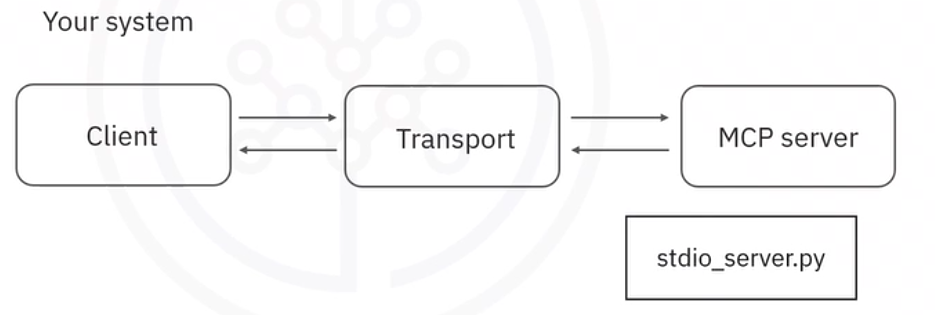
- file
- 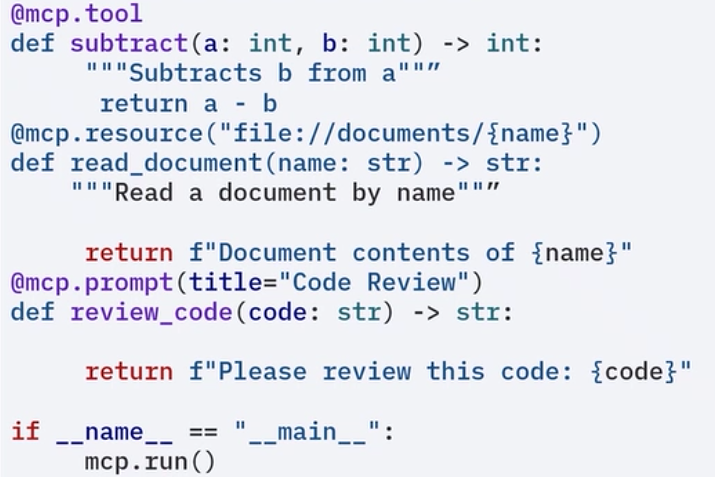